In [1]:
import pandas as pd

from src.evaluate import AllMetrics
from src.visualise import plot_all

# Baseline model evaluation

In [2]:
from src.models import MovingAverageModel

ACTUAL_COL = 'points_next_three'
PREDICTED_COL = 'prediction_next_three'

# Load and predict
df = pd.read_csv('data/merged_data.csv')
model = MovingAverageModel(window=3)
df = model.predict(df)

print(f'Rows: {len(df)}, Seasons: {sorted(df["season"].unique())}')
df[['name', 'season', 'GW', ACTUAL_COL, PREDICTED_COL]].head(5)

/var/folders/wx/6l7zgh9x4cd0fjqhbd7hzs_00000gn/T/ipykernel_23288/1226459922.py:7: DtypeWarning: Columns (25,57,58,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/merged_data.csv')


Rows: 192689, Seasons: ['2016-17', '2017-18', '2018-19', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']


,name,season,GW,points_next_three,prediction_next_three
165770,Aaron_Anselmino,2024-25,25,0.0,NaN
165771,Aaron_Anselmino,2024-25,26,0.0,0.0
165772,Aaron_Anselmino,2024-25,27,0.0,0.0
165773,Aaron_Anselmino,2024-25,28,0.0,0.0
165774,Aaron_Anselmino,2024-25,29,0.0,0.0


Now compute metrics and plot them.

 season  mean_absolute_error  rank_correlation
2016-17                3.154             0.695
2017-18                3.343             0.674
2018-19                3.438             0.665
2020-21                3.123             0.686
2021-22                3.163             0.681
2022-23                2.899             0.713
2023-24                2.647             0.711
2024-25                2.745             0.720


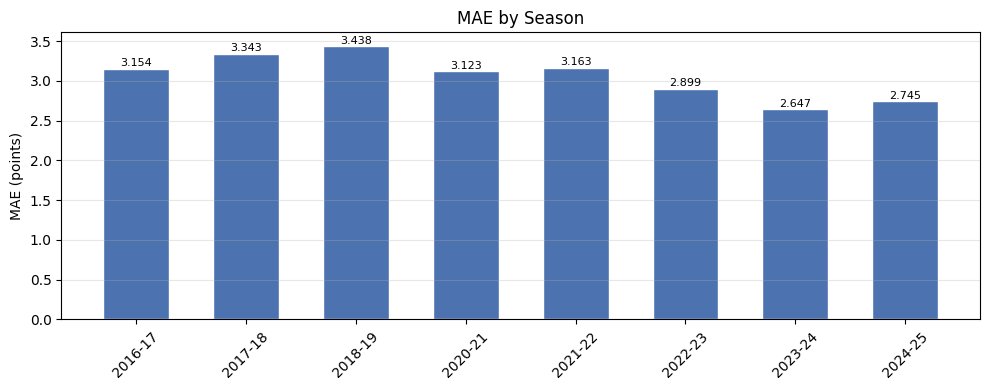

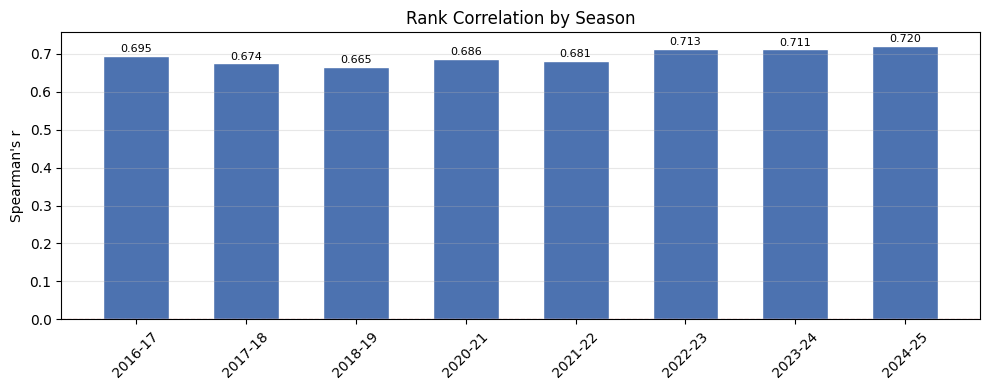

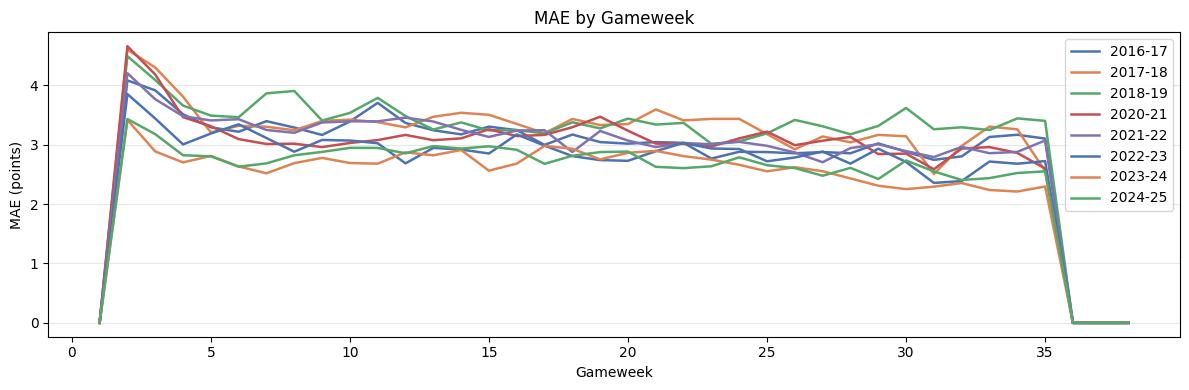

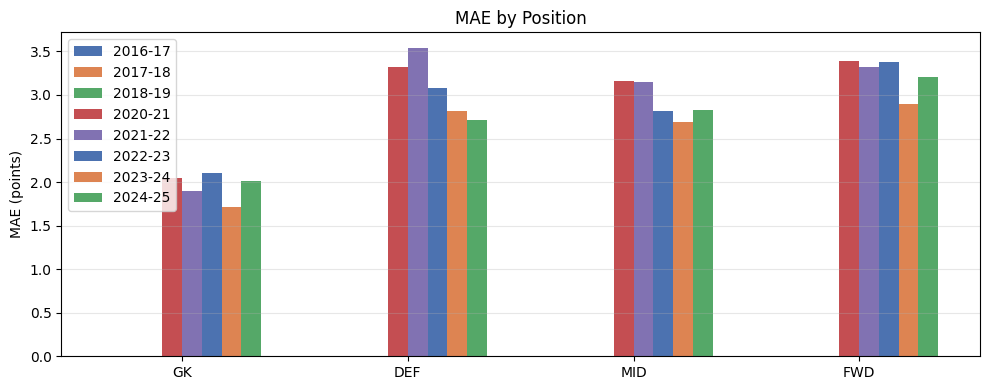

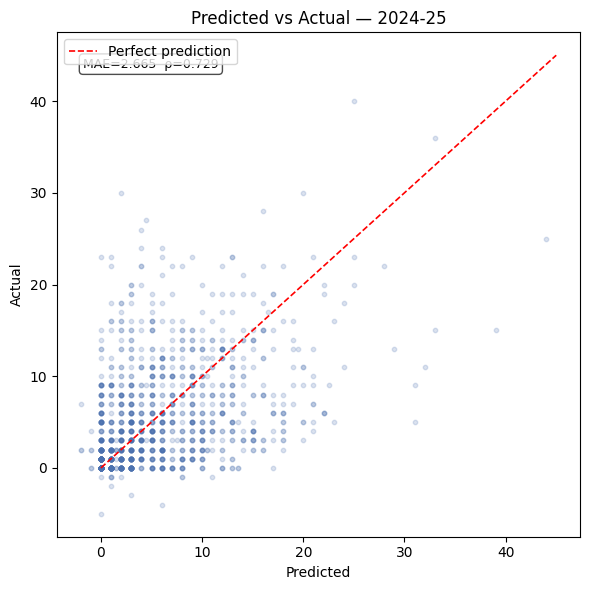

In [3]:
all_metrics = AllMetrics.from_dataframe(df, actual_col=ACTUAL_COL, predicted_col=PREDICTED_COL)

print(all_metrics.summary().to_string(index=False))

plot_all(all_metrics, df, actual_col=ACTUAL_COL, predicted_col=PREDICTED_COL)

# Ridge Regression model

In [4]:
from src.train_model import load_feature_names, seasonal_split, ridge_model, tune_ridge_alpha, train_and_predict
from src.constants import DATA_DIR

# Load data with features
data_path = DATA_DIR / "data_with_features.csv"
feature_config_path = DATA_DIR / "all_feature_names.json"

print(f"Loading data from {data_path}")
df_ridge = pd.read_csv(data_path)

print(f"Loading feature configuration from {feature_config_path}")
feature_cols = load_feature_names(feature_config_path)
print(f"Using {len(feature_cols)} features: {feature_cols}")

Loading data from data/data_with_features.csv
Loading feature configuration from data/all_feature_names.json
Using 18 features: ['total_points_last_1', 'total_points_last_3', 'total_points_last_5', 'minutes_last_1', 'minutes_last_3', 'minutes_last_5', 'expected_goals_last_1', 'expected_goals_last_3', 'expected_goals_last_5', 'expected_assists_last_1', 'expected_assists_last_3', 'expected_assists_last_5', 'expected_goals_conceded_last_1', 'expected_goals_conceded_last_3', 'expected_goals_conceded_last_5', 'bonus_last_1', 'bonus_last_3', 'bonus_last_5']


In [5]:
TEST_SEASONS = ["2023-24", "2024-25"]
TRAIN_SEASONS = [s for s in df_ridge["season"].unique() if s not in TEST_SEASONS]
TARGET = "points_next_three"

best_alpha = tune_ridge_alpha(
    df=df_ridge,
    target_col=TARGET,
    feature_cols=feature_cols,
    train_seasons=TRAIN_SEASONS,
    cv_splits=3,
)

df_ridge, ridge_metrics = train_and_predict(
    df=df_ridge,
    model=ridge_model(alpha=best_alpha),
    target_col=TARGET,
    test_seasons=TEST_SEASONS,
    feature_cols=feature_cols,
    prediction_col="predicted_pts",
    verbose=True,
)

final_model = ridge_model(alpha=best_alpha)
train_df, test_df = seasonal_split(df_ridge, TEST_SEASONS)
train_clean = train_df.dropna(subset=feature_cols + [TARGET])
X_train = train_clean[feature_cols]
y_train = train_clean[TARGET]
final_model.fit(X_train, y_train)


Seasonal cross-validation (3 folds):
  Fold 1: train on 2016-17 to 2018-19, validate on 2020-21
  Fold 2: train on 2016-17 to 2020-21, validate on 2021-22
  Fold 3: train on 2016-17 to 2021-22, validate on 2022-23

  Best alpha: 0.01
  Best CV MAE: 3.0481

PERFORMANCE DIAGNOSTICS

Train set (124576 samples):
  MAE:        3.0950
  Spearman R: 0.6960

Test set (50718 samples):
  MAE:        2.7648
  Spearman R: 0.7237

Generalisation gap:
  MAE gap:        -0.3303 (-10.7%)
  Spearman gap:   -0.0277 (-4.0%)

Overfitting check:
  ✓  Reasonable generalization



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['total_points_last_1','total_points_last_3','total_points_last_5',..., 'bonus_last_1','bonus_last_3','bonus_last_5']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


Now evaluate the ridge model

 season  mean_absolute_error  rank_correlation
2016-17                  NaN               NaN
2017-18                  NaN               NaN
2018-19                  NaN               NaN
2020-21                  NaN               NaN
2021-22                  NaN               NaN
2022-23                  NaN               NaN
2023-24                2.754             0.719
2024-25                2.776             0.728


/Users/ollie/code/FPL-Oracle/src/evaluate.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(clean[actual_col], clean[predicted_col])
/Users/ollie/code/FPL-Oracle/src/evaluate.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(clean[actual_col], clean[predicted_col])


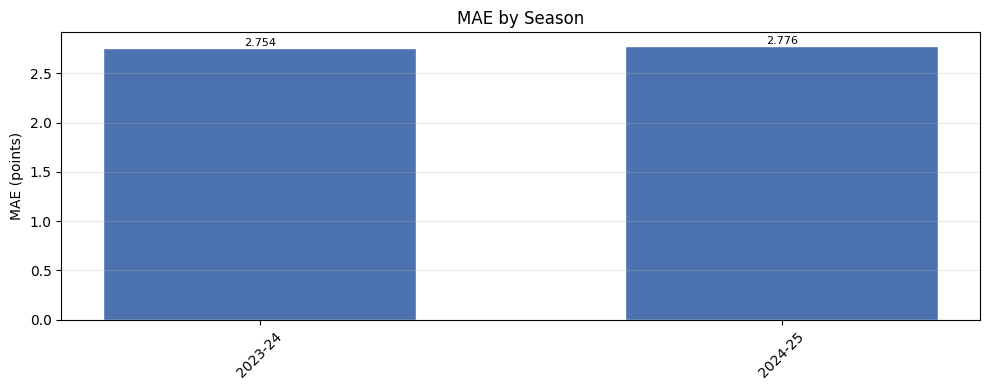

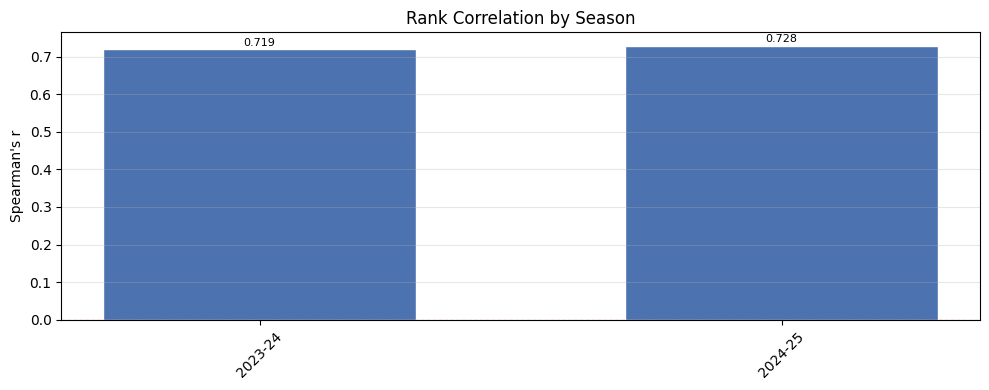

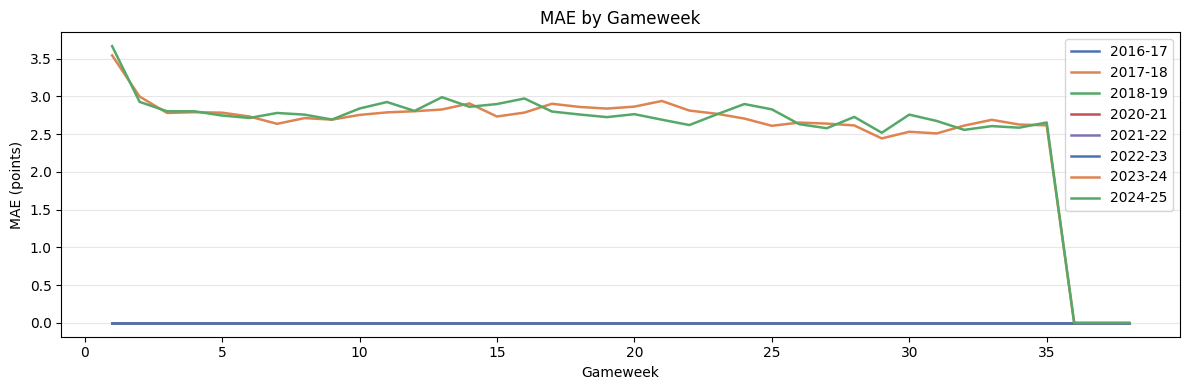

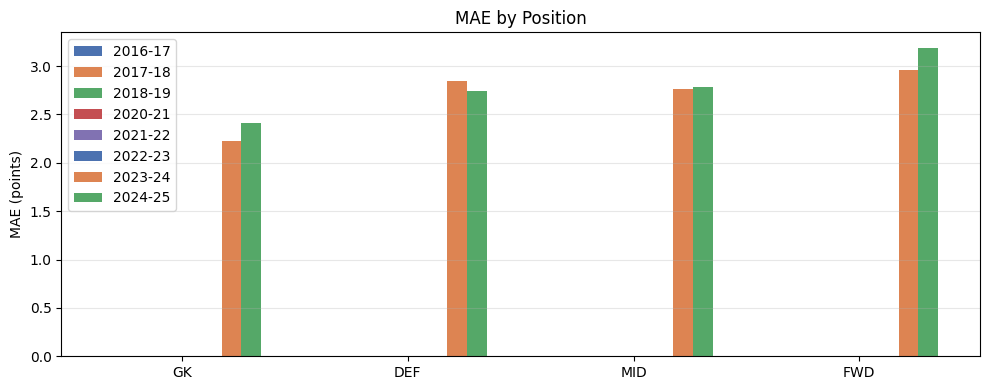

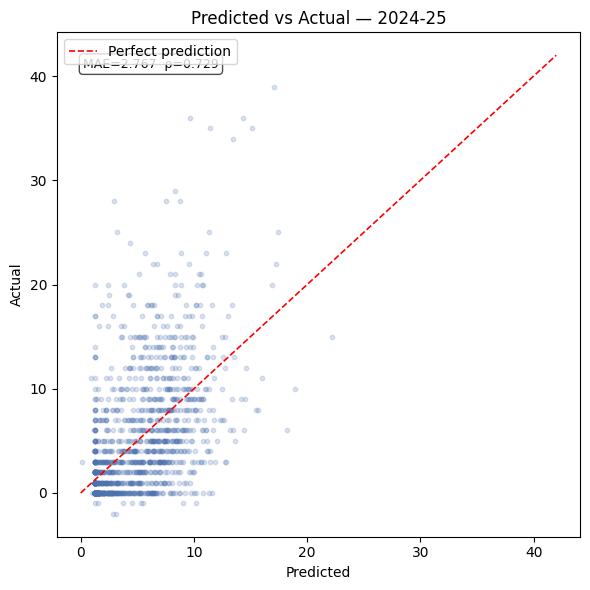

In [6]:
RIDGE_ACTUAL_COL = TARGET
RIDGE_PREDICTED_COL = "predicted_pts"

ridge_all_metrics = AllMetrics.from_dataframe(
    df_ridge, 
    actual_col=RIDGE_ACTUAL_COL, 
    predicted_col=RIDGE_PREDICTED_COL
)

print(ridge_all_metrics.summary().to_string(index=False))
plot_all(ridge_all_metrics, df_ridge, actual_col=RIDGE_ACTUAL_COL, predicted_col=RIDGE_PREDICTED_COL)

## Feature Importance (Ridge Coefficients)

Top 10 most important features (by absolute coefficient):
                       feature  coefficient  abs_coefficient
           total_points_last_5     1.690526         1.690526
                minutes_last_1     1.198162         1.198162
                minutes_last_5     0.511831         0.511831
           total_points_last_3     0.312509         0.312509
                  bonus_last_5    -0.284165         0.284165
           total_points_last_1     0.181142         0.181142
       expected_assists_last_5     0.135528         0.135528
         expected_goals_last_5     0.121778         0.121778
expected_goals_conceded_last_5    -0.115762         0.115762
                  bonus_last_3    -0.103400         0.103400


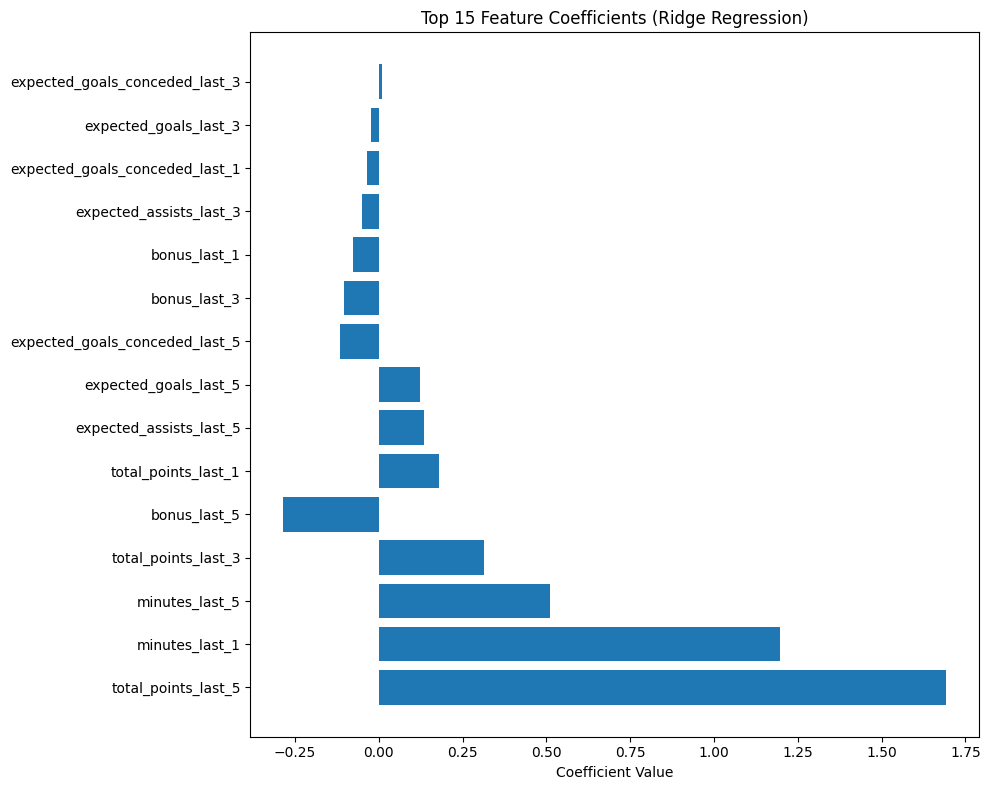

In [7]:
import matplotlib.pyplot as plt

# Extract coefficients from the Ridge model
ridge_regressor = final_model.named_steps['model']
coefficients = ridge_regressor.coef_
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': coefficients,
    'abs_coefficient': abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("Top 10 most important features (by absolute coefficient):")
print(coef_df.head(10).to_string(index=False))

# Plot coefficients
plt.figure(figsize=(10, 8))
plt.barh(coef_df['feature'].head(15), coef_df['coefficient'].head(15))
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients (Ridge Regression)')
plt.tight_layout()
plt.show()